# Simulación de las Perdidas Esperadas (EL), Perdidas Inesperadas(UL) y el Valor en Riesgo (VaR)

## Parametrización de la Simulación

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
# 1. Cargar datos (ajusta la ruta y nombres de columna)
df = pd.read_excel("Cred1.xlsx")  # columnas: E, DP, r

E  = df["Saldo"].to_numpy()
DP = df["Prob_Incumplimiento"].to_numpy()



In [13]:
# Parametrización de la simulación

n_credits = len(E) #Número de créditos
M = 100000  # número de simulaciones

# Se supone que la tasa de recuperación sigue una distribución normal con 
# media mu_r y desviación estándar sigma_r
mu_r = 0.4
sigma_r = 0.15

#Se crea un nuevo generador de números aleatorios de NumPy y fija la semilla del generador. 
rng = np.random.default_rng(seed=1234)

## Simulación de montecarlo (IRB - Basilea)

In [14]:
# 2. Simular incumplimientos: matriz M x n_credits de Bernoulli(DP_i)
# Usamos broadcasting: DP tiene forma (n_credits,)
incumplimientos = rng.random(size=(M, n_credits)) < DP  # booleano -> 0/1

# 3. Simular recuperaciones: N(mu_r, sigma_r), truncadas a [0,1]
recuperaciones = rng.normal(loc=mu_r, scale=sigma_r, size=(M, n_credits))
recuperaciones = np.clip(recuperaciones, 0.0, 1.0)



### Vista de las Distribuciones

In [ ]:
# Histograma de incumplimientos y recuperaciones simuladas
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

# Convertimos las matrices a vectores para graficar
incumplimientos_vec = incumplimientos.ravel()
recuperaciones_vec = recuperaciones.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(incumplimientos_vec, bins=2, range=(0, 1), alpha=0.8, color="#4C72B0", edgecolor="black")
axes[0].set_title("Distribución de incumplimientos simulados")
axes[0].set_xlabel("Estado de incumplimiento (0 o 1)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No incumple", "Incumple"])

axes[1].hist(recuperaciones_vec, bins=30, range=(0, 1), alpha=0.8, color="#55A868", edgecolor="black")
axes[1].set_title("Distribución de recuperaciones simuladas")
axes[1].set_xlabel("Tasa de recuperación")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# 4. Calcular pérdida por crédito y por simulación
# L_i = E_i * I_i * (1 - r_i_sim)
perdidas_por_credito = E * incumplimientos * (1.0 - recuperaciones)  # M x n_credits
perdidas_cartera = perdidas_por_credito.sum(axis=1)                  # M valores



### Resultados

In [ ]:
import numpy as np

# perdidas_cartera: array de tamaño M con la pérdida total en cada simulación

# 1. Pérdida esperada (EL)
EL = perdidas_cartera.mean()

# 2. Pérdida inesperada (UL)
UL = perdidas_cartera.std()

# 3. VaR al 99% (nivel de pérdida)
VaR_99 = np.percentile(perdidas_cartera, 99)

# 4. CreditVaR al 99% (capital económico = exceso sobre EL)
CreditVaR_99 = VaR_99 - EL

print(f"EL (pérdida esperada)        : {EL:,.2f}")
print(f"UL (pérdida inesperada)      : {UL:,.2f}")
print(f"VaR 99% (nivel de pérdida)   : {VaR_99:,.2f}")
print(f"CreditVaR 99% (capital)      : {CreditVaR_99:,.2f}")

EL (pérdida esperada)        : 6,893,639.09
UL (pérdida inesperada)      : 305,218.02
VaR 99% (nivel de pérdida)   : 7,613,819.40
CreditVaR 99% (capital)      : 720,180.31


### Gráficas de la Distribución de Pérdidas

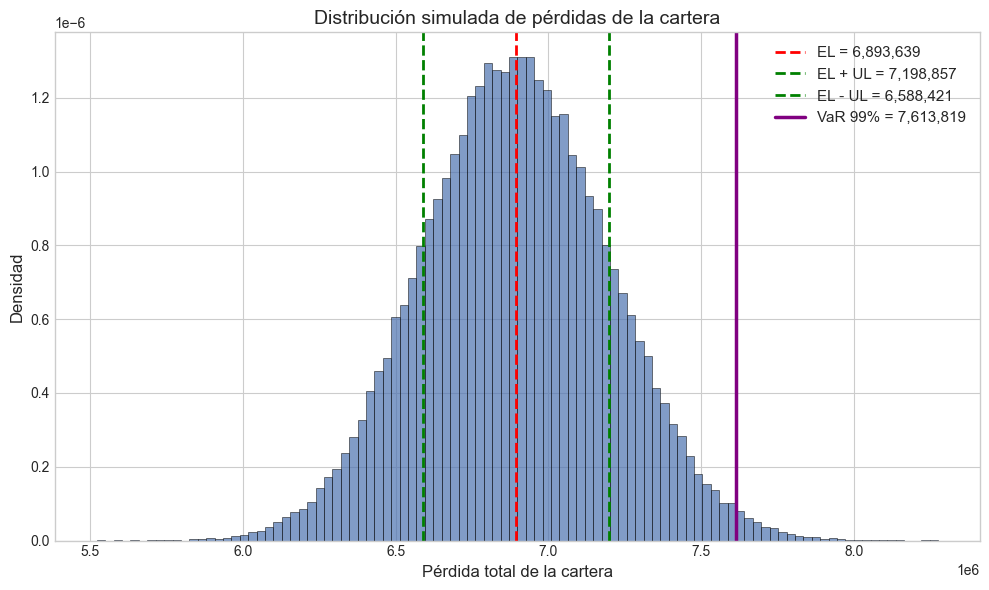

In [ ]:
# -------------------------
# 4. Histograma con EL, UL y VaR 99%
# -------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma de densidad
ax.hist(perdidas_cartera, bins=100, density=True,
        alpha=0.7, color="#4C72B0", edgecolor="black", linewidth=0.5)

# Línea de pérdida esperada (EL)
ax.axvline(EL, color="red", linestyle="--", linewidth=2,
           label=f"EL = {EL:,.0f}")

# Líneas de EL ± UL (pérdida inesperada)
ax.axvline(EL + UL, color="green", linestyle="--", linewidth=2,
           label=f"EL + UL = {EL+UL:,.0f}")
ax.axvline(EL - UL, color="green", linestyle="--", linewidth=2,
           label=f"EL - UL = {EL-UL:,.0f}")

# Línea de VaR 99%
ax.axvline(VaR_99, color="purple", linestyle="-", linewidth=2.5,
           label=f"VaR 99% = {VaR_99:,.0f}")

ax.set_title("Distribución simulada de pérdidas de la cartera", fontsize=14)
ax.set_xlabel("Pérdida total de la cartera", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
##plt.savefig("output/histograma_perdidas_cartera.png", dpi=300)
plt.show()